# Tax-Aware Position Risk Simulation

This notebook compares selling now and paying capital gains tax against holding through possible future price moves. It also tests probability-weighted scenarios and stop-loss thresholds after tax.

Update the inputs in the next cell with your own numbers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.float_format = "{:,.2f}".format

## Inputs

In [2]:
# Replace these example values with your real position data.
shares = 350
current_price = 350.0
cost_basis_per_share = 123.0
capital_gains_tax_rate = 0.26

# Sensitivity range for possible future price moves from today's price.
min_return = -0.80
max_return = 1.00
return_step = 0.01

# Probability-weighted scenarios. Probabilities must add up to 1.0.
scenario_cases = pd.DataFrame({
    "case": ["Bear", "Base", "Bull"],
    "return": [-0.20, 0.05, 0.25],
    "probability": [0.45, 0.15, 0.40],
})

# Candidate stop losses, expressed as drops from today's price.
stop_loss_drops = np.array([0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50])

# Bear-market recovery assumptions.
# drawdown is the bear-market drop from today's price.
# recovery_return_from_low is the rebound from that drawdown price if recovery happens.
# recovery_probability is the chance that rebound happens instead of remaining at the drawdown price.
bear_recovery_cases = pd.DataFrame({
    "case": ["Bear -20%", "Bear -30%", "Bear -40%", "Bear -50%"],
    "drawdown": [-0.20, -0.30, -0.40, -0.50],
    "recovery_return_from_low": [0.25, 0.45, 0.70, 1.00],
    "recovery_probability": [0.60, 0.45, 0.30, 0.20],
})

probability_sum = scenario_cases["probability"].sum()
assert np.isclose(probability_sum, 1.0), f"Scenario probabilities add up to {probability_sum:.4f}, not 1.0"

scenario_cases

,case,return,probability
0,Bear,-0.20,0.45
1,Base,0.05,0.15
2,Bull,0.25,0.40


## Core Functions

In [3]:
def taxable_gain_at_sale(price, shares, basis_per_share):
    return max((price - basis_per_share) * shares, 0)


def tax_due_at_sale(price, shares, basis_per_share, tax_rate):
    return taxable_gain_at_sale(price, shares, basis_per_share) * tax_rate


def after_tax_liquidation_value(price, shares, basis_per_share, tax_rate):
    gross_value = price * shares
    tax_due = tax_due_at_sale(price, shares, basis_per_share, tax_rate)
    return gross_value - tax_due


def after_tax_value_for_return(return_from_today):
    future_price = current_price * (1 + return_from_today)
    return after_tax_liquidation_value(
        future_price, shares, cost_basis_per_share, capital_gains_tax_rate
    )


def required_price_for_after_tax_value(target_after_tax_value):
    low = 0.0
    high = max(current_price * 10, cost_basis_per_share * 10, 1.0)

    while after_tax_liquidation_value(high, shares, cost_basis_per_share, capital_gains_tax_rate) < target_after_tax_value:
        high *= 2

    for _ in range(100):
        mid = (low + high) / 2
        value = after_tax_liquidation_value(mid, shares, cost_basis_per_share, capital_gains_tax_rate)
        if value < target_after_tax_value:
            low = mid
        else:
            high = mid

    return high

## Sell Now Baseline

In [4]:
current_value = current_price * shares
current_unrealized_gain = taxable_gain_at_sale(current_price, shares, cost_basis_per_share)
sell_now_tax = current_unrealized_gain * capital_gains_tax_rate
sell_now_after_tax = current_value - sell_now_tax

baseline = pd.Series({
    "shares": shares,
    "current_price": current_price,
    "cost_basis_per_share": cost_basis_per_share,
    "current_gross_value": current_value,
    "current_unrealized_gain": current_unrealized_gain,
    "tax_if_sold_now": sell_now_tax,
    "after_tax_value_if_sold_now": sell_now_after_tax,
})

baseline

shares                            350.00
current_price                     350.00
cost_basis_per_share              123.00
current_gross_value           122,500.00
current_unrealized_gain        79,450.00
tax_if_sold_now                20,657.00
after_tax_value_if_sold_now   101,843.00
dtype: float64

## Return Sensitivity

This table asks: if the future price move is X%, what would the after-tax liquidation value be? The 0% row should match selling today because the price and tax bill are unchanged.

In [5]:
future_returns = np.arange(min_return, max_return + return_step, return_step)
future_prices = current_price * (1 + future_returns)

sensitivity_df = pd.DataFrame({
    "return": future_returns,
    "future_price": future_prices,
})

sensitivity_df["after_tax_value_if_sold_later"] = sensitivity_df["future_price"].apply(
    lambda p: after_tax_liquidation_value(p, shares, cost_basis_per_share, capital_gains_tax_rate)
)
sensitivity_df["tax_if_sold_later"] = sensitivity_df["future_price"].apply(
    lambda p: tax_due_at_sale(p, shares, cost_basis_per_share, capital_gains_tax_rate)
)
sensitivity_df["advantage_vs_selling_now"] = (
    sensitivity_df["after_tax_value_if_sold_later"] - sell_now_after_tax
)

zero_move = sensitivity_df.loc[sensitivity_df["return"].abs().idxmin()]

pd.Series({
    "value_if_sold_now": sell_now_after_tax,
    "value_if_sold_later_at_0pct_move": zero_move["after_tax_value_if_sold_later"],
    "difference_at_0pct_move": zero_move["advantage_vs_selling_now"],
})

value_if_sold_now                  101,843.00
value_if_sold_later_at_0pct_move   101,843.00
difference_at_0pct_move                  0.00
dtype: float64

## Sensitivity Chart

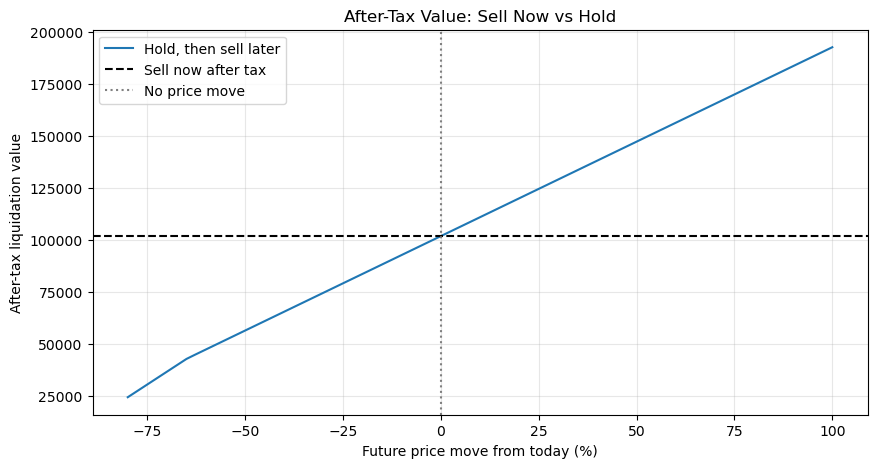

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    sensitivity_df["return"] * 100,
    sensitivity_df["after_tax_value_if_sold_later"],
    label="Hold, then sell later",
)
ax.axhline(sell_now_after_tax, color="black", linestyle="--", label="Sell now after tax")
ax.axvline(0, color="gray", linestyle=":", label="No price move")
ax.set_title("After-Tax Value: Sell Now vs Hold")
ax.set_xlabel("Future price move from today (%)")
ax.set_ylabel("After-tax liquidation value")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Probability-Weighted Scenarios

This is where expected upside/downside is modeled. Edit the bear/base/bull returns and probabilities in the input cell.

`weighted_after_tax_value` is the scenario's after-tax liquidation value multiplied by that scenario's probability. Adding this column gives the expected after-tax value of holding.

`weighted_difference_vs_selling_now` is the scenario's advantage or disadvantage versus selling today, multiplied by that scenario's probability. Adding this column gives the expected gain or loss from holding instead of selling now.

In [7]:
weighted_df = scenario_cases.copy()
weighted_df["future_price"] = current_price * (1 + weighted_df["return"])
weighted_df["after_tax_value"] = weighted_df["future_price"].apply(
    lambda p: after_tax_liquidation_value(p, shares, cost_basis_per_share, capital_gains_tax_rate)
)
weighted_df["tax_due"] = weighted_df["future_price"].apply(
    lambda p: tax_due_at_sale(p, shares, cost_basis_per_share, capital_gains_tax_rate)
)
weighted_df["difference_vs_selling_now"] = weighted_df["after_tax_value"] - sell_now_after_tax
weighted_df["weighted_after_tax_value"] = weighted_df["after_tax_value"] * weighted_df["probability"]
weighted_df["weighted_difference_vs_selling_now"] = (
    weighted_df["difference_vs_selling_now"] * weighted_df["probability"]
)

expected_hold_after_tax = weighted_df["weighted_after_tax_value"].sum()
expected_hold_advantage = expected_hold_after_tax - sell_now_after_tax

weighted_df

,case,return,probability,future_price,after_tax_value,tax_due,difference_vs_selling_now,weighted_after_tax_value,weighted_difference_vs_selling_now
0,Bear,-0.20,0.45,280.00,"83,713.00","14,287.00","-18,130.00","37,670.85","-8,158.50"
1,Base,0.05,0.15,367.50,"106,375.50","22,249.50","4,532.50","15,956.32",679.88
2,Bull,0.25,0.40,437.50,"124,505.50","28,619.50","22,662.50","49,802.20","9,065.00"


In [8]:
pd.Series({
    "sell_now_after_tax_value": sell_now_after_tax,
    "expected_hold_after_tax_value": expected_hold_after_tax,
    "expected_hold_advantage_vs_selling_now": expected_hold_advantage,
})

sell_now_after_tax_value                 101,843.00
expected_hold_after_tax_value            103,429.38
expected_hold_advantage_vs_selling_now     1,586.38
dtype: float64

## Stop-Loss Expected Value

For each stop loss, this assumes the stop executes exactly at the stop price when a scenario return is below the threshold. If the scenario return is above the stop threshold, the model uses the scenario's final return.

The probabilities come from the `scenario_cases` input table. In the default model, that means the Bear, Base, and Bull probabilities. For each stop-loss rule, the notebook calculates one after-tax outcome for Bear, one for Base, and one for Bull, then multiplies each outcome by its own probability and adds them together.

`stop_loss_drop` is the stop threshold expressed as a percentage drop from the current price. A value of `0.20` means a 20% stop loss.

`stop_price` is the price where that stop loss would trigger.

`after_tax_value_if_stop_hits` is the after-tax cash value if the position is sold exactly at the stop price. This is not probability-weighted; it is the value at the stop price itself.

`expected_after_tax_value_with_stop` is the sum of the Bear/Base/Bull after-tax outcomes after applying that stop-loss rule, weighted by their probabilities from `scenario_cases`.

`expected_difference_vs_selling_now` compares that probability-weighted stop-loss result against selling immediately. Positive means the stop-loss strategy has a higher expected after-tax value than selling now.

`expected_difference_vs_no_stop_hold` compares that probability-weighted stop-loss result against holding without a stop loss. Positive means the stop-loss rule improves expected after-tax value versus simply holding through the modeled scenarios.

In [9]:
stop_rows = []

for drop in stop_loss_drops:
    stop_return = -drop
    scenario_values = []

    for _, scenario in scenario_cases.iterrows():
        realized_return = max(scenario["return"], stop_return)
        realized_price = current_price * (1 + realized_return)
        after_tax_value = after_tax_liquidation_value(
            realized_price, shares, cost_basis_per_share, capital_gains_tax_rate
        )
        scenario_values.append(after_tax_value * scenario["probability"])

    expected_after_tax_value = sum(scenario_values)
    stop_price = current_price * (1 - drop)
    after_tax_value_at_stop = after_tax_liquidation_value(
        stop_price, shares, cost_basis_per_share, capital_gains_tax_rate
    )

    stop_rows.append({
        "stop_loss_drop": drop,
        "stop_price": stop_price,
        "after_tax_value_if_stop_hits": after_tax_value_at_stop,
        "expected_after_tax_value_with_stop": expected_after_tax_value,
        "expected_difference_vs_selling_now": expected_after_tax_value - sell_now_after_tax,
        "expected_difference_vs_no_stop_hold": expected_after_tax_value - expected_hold_after_tax,
    })

stop_df = pd.DataFrame(stop_rows)
stop_df

,stop_loss_drop,stop_price,after_tax_value_if_stop_hits,expected_after_tax_value_with_stop,expected_difference_vs_selling_now,expected_difference_vs_no_stop_hold
0,0.05,332.50,"97,310.50","109,548.25","7,705.25","6,118.88"
1,0.10,315.00,"92,778.00","107,508.62","5,665.62","4,079.25"
2,0.15,297.50,"88,245.50","105,469.00","3,626.00","2,039.62"
3,0.20,280.00,"83,713.00","103,429.38","1,586.38",0.00
4,0.25,262.50,"79,180.50","103,429.38","1,586.38",0.00
5,0.30,245.00,"74,648.00","103,429.38","1,586.38",0.00
6,0.40,210.00,"65,583.00","103,429.38","1,586.38",0.00
7,0.50,175.00,"56,518.00","103,429.38","1,586.38",0.00


## Bear-Market Recovery Analysis

This section is closer to the stop-loss question: if the market is already in a bear drawdown, is it better to keep holding and hope for a recovery, or would selling now and paying tax have been better?

The recovery probabilities come from `bear_recovery_cases`, not from the Bear/Base/Bull table. For each drawdown, the model compares three things:

`after_tax_value_if_sold_at_drawdown` is what you would have if a stop sold exactly at the drawdown price.

`required_recovery_price_to_match_selling_now` is the future recovery price needed to equal selling today after tax.

`expected_after_tax_value_if_hold_for_recovery` is the probability-weighted value of holding after the drawdown: recovery value times recovery probability, plus drawdown value times the probability that recovery does not happen.

If `expected_difference_vs_selling_now` is positive, then holding through that bear drawdown has a higher expected after-tax value than selling today under your recovery assumptions. If it is negative, selling today is better under those assumptions.

In [10]:
recovery_rows = []
required_recovery_price = required_price_for_after_tax_value(sell_now_after_tax)

for _, case in bear_recovery_cases.iterrows():
    drawdown_price = current_price * (1 + case["drawdown"])
    recovery_price = drawdown_price * (1 + case["recovery_return_from_low"])

    after_tax_at_drawdown = after_tax_liquidation_value(
        drawdown_price, shares, cost_basis_per_share, capital_gains_tax_rate
    )
    after_tax_after_recovery = after_tax_liquidation_value(
        recovery_price, shares, cost_basis_per_share, capital_gains_tax_rate
    )

    expected_hold_for_recovery = (
        case["recovery_probability"] * after_tax_after_recovery
        + (1 - case["recovery_probability"]) * after_tax_at_drawdown
    )

    required_recovery_return_from_low = (required_recovery_price / drawdown_price) - 1

    recovery_rows.append({
        "case": case["case"],
        "drawdown": case["drawdown"],
        "drawdown_price": drawdown_price,
        "after_tax_value_if_sold_at_drawdown": after_tax_at_drawdown,
        "recovery_return_from_low": case["recovery_return_from_low"],
        "recovery_price": recovery_price,
        "recovery_probability": case["recovery_probability"],
        "after_tax_value_if_recovery_happens": after_tax_after_recovery,
        "expected_after_tax_value_if_hold_for_recovery": expected_hold_for_recovery,
        "expected_difference_vs_selling_now": expected_hold_for_recovery - sell_now_after_tax,
        "required_recovery_price_to_match_selling_now": required_recovery_price,
        "required_recovery_return_from_low_to_match_selling_now": required_recovery_return_from_low,
    })

bear_recovery_df = pd.DataFrame(recovery_rows)
bear_recovery_df

,case,drawdown,drawdown_price,after_tax_value_if_sold_at_drawdown,recovery_return_from_low,recovery_price,recovery_probability,after_tax_value_if_recovery_happens,expected_after_tax_value_if_hold_for_recovery,expected_difference_vs_selling_now,required_recovery_price_to_match_selling_now,required_recovery_return_from_low_to_match_selling_now
0,Bear -20%,-0.20,280.00,"83,713.00",0.25,350.00,0.60,"101,843.00","94,591.00","-7,252.00",350.00,0.25
1,Bear -30%,-0.30,245.00,"74,648.00",0.45,355.25,0.45,"103,202.75","87,497.64","-14,345.36",350.00,0.43
2,Bear -40%,-0.40,210.00,"65,583.00",0.70,357.00,0.30,"103,656.00","77,004.90","-24,838.10",350.00,0.67
3,Bear -50%,-0.50,175.00,"56,518.00",1.00,350.00,0.20,"101,843.00","65,583.00","-36,260.00",350.00,1.00


## Stop-Loss Benchmark Table and Chart

This table turns the candidate stop losses into benchmarks. For each stop level, it shows the after-tax value if the stop executes there and the recovery needed from that stop price to match selling today after tax.

`required_recovery_from_stop_to_match_selling_now` is the key benchmark. It answers: if I let the position fall to this stop price, how much does it need to rebound from there before holding becomes as good as selling today?

With a flat capital-gains tax, the required recovery price will usually be today's price. The useful part is the recovery percentage from the lower stop price.

In [11]:
benchmark_rows = []
required_recovery_price = required_price_for_after_tax_value(sell_now_after_tax)

for drop in stop_loss_drops:
    stop_price = current_price * (1 - drop)
    after_tax_at_stop = after_tax_liquidation_value(
        stop_price, shares, cost_basis_per_share, capital_gains_tax_rate
    )
    required_recovery_from_stop = (required_recovery_price / stop_price) - 1

    benchmark_rows.append({
        "stop_loss_drop": drop,
        "stop_price": stop_price,
        "after_tax_value_if_stopped": after_tax_at_stop,
        "after_tax_loss_vs_selling_now": after_tax_at_stop - sell_now_after_tax,
        "after_tax_loss_vs_selling_now_pct": (after_tax_at_stop / sell_now_after_tax) - 1,
        "required_recovery_price_to_match_selling_now": required_recovery_price,
        "required_recovery_from_stop_to_match_selling_now": required_recovery_from_stop,
    })

stop_benchmark_df = pd.DataFrame(benchmark_rows)
stop_benchmark_df

,stop_loss_drop,stop_price,after_tax_value_if_stopped,after_tax_loss_vs_selling_now,after_tax_loss_vs_selling_now_pct,required_recovery_price_to_match_selling_now,required_recovery_from_stop_to_match_selling_now
0,0.05,332.50,"97,310.50","-4,532.50",-0.04,350.00,0.05
1,0.10,315.00,"92,778.00","-9,065.00",-0.09,350.00,0.11
2,0.15,297.50,"88,245.50","-13,597.50",-0.13,350.00,0.18
3,0.20,280.00,"83,713.00","-18,130.00",-0.18,350.00,0.25
4,0.25,262.50,"79,180.50","-22,662.50",-0.22,350.00,0.33
5,0.30,245.00,"74,648.00","-27,195.00",-0.27,350.00,0.43
6,0.40,210.00,"65,583.00","-36,260.00",-0.36,350.00,0.67
7,0.50,175.00,"56,518.00","-45,325.00",-0.45,350.00,1.00


In [12]:
benchmark_risk_tolerance = 0.30
best_benchmark_stop = stop_benchmark_df[
    stop_benchmark_df["required_recovery_from_stop_to_match_selling_now"] <= benchmark_risk_tolerance
].tail(1)

if best_benchmark_stop.empty:
    best_benchmark_stop = stop_benchmark_df.head(1)
    benchmark_note = (
        f"No tested stop has a required recovery at or below {benchmark_risk_tolerance:.0%}. "
        "The tightest tested stop is shown instead."
    )
else:
    benchmark_note = (
        f"Deepest tested stop where required recovery is at or below {benchmark_risk_tolerance:.0%}."
    )

best_benchmark_stop = best_benchmark_stop.iloc[0]

pd.Series({
    "benchmark_rule": benchmark_note,
    "best_benchmark_stop_loss_drop": best_benchmark_stop["stop_loss_drop"],
    "best_benchmark_stop_price": best_benchmark_stop["stop_price"],
    "after_tax_value_if_stopped": best_benchmark_stop["after_tax_value_if_stopped"],
    "after_tax_loss_vs_selling_now": best_benchmark_stop["after_tax_loss_vs_selling_now"],
    "required_recovery_price_to_match_selling_now": best_benchmark_stop["required_recovery_price_to_match_selling_now"],
    "required_recovery_from_stop_to_match_selling_now": best_benchmark_stop["required_recovery_from_stop_to_match_selling_now"],
})

benchmark_rule                                      Deepest tested stop where required recovery is...
best_benchmark_stop_loss_drop                                                                    0.20
best_benchmark_stop_price                                                                      280.00
after_tax_value_if_stopped                                                                  83,713.00
after_tax_loss_vs_selling_now                                                              -18,130.00
required_recovery_price_to_match_selling_now                                                   350.00
required_recovery_from_stop_to_match_selling_now                                                 0.25
dtype: object

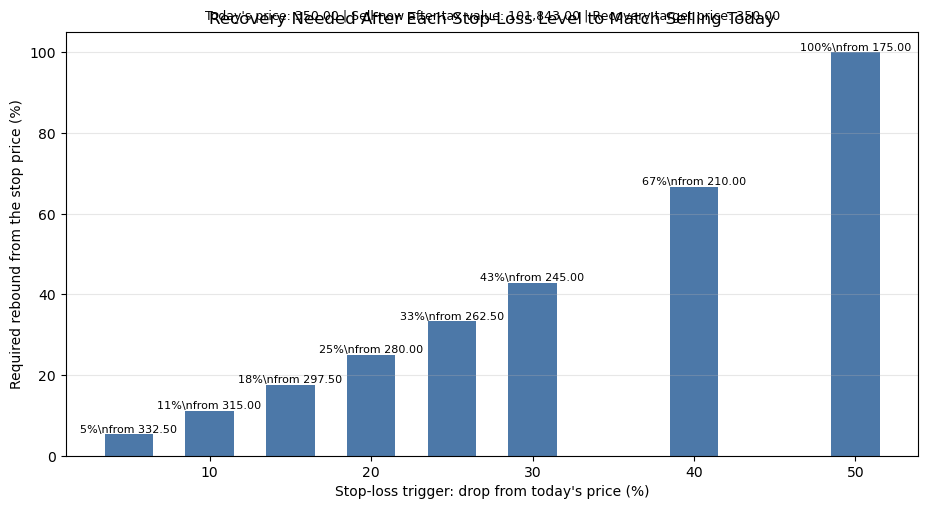

In [13]:
fig, ax = plt.subplots(figsize=(11, 5.5))

x = stop_benchmark_df["stop_loss_drop"] * 100
y = stop_benchmark_df["required_recovery_from_stop_to_match_selling_now"] * 100

ax.bar(x, y, width=3, color="#4C78A8")
ax.set_title("Recovery Needed After Each Stop-Loss Level to Match Selling Today")
ax.set_xlabel("Stop-loss trigger: drop from today's price (%)")
ax.set_ylabel("Required rebound from the stop price (%)")
ax.grid(True, axis="y", alpha=0.3)

subtitle = (
    f"Today's price: {current_price:,.2f} | "
    f"Sell-now after-tax value: {sell_now_after_tax:,.2f} | "
    f"Recovery target price: {required_recovery_price:,.2f}"
)
ax.text(0.5, 1.03, subtitle, transform=ax.transAxes, ha="center", fontsize=9)

for _, row in stop_benchmark_df.iterrows():
    ax.text(
        row["stop_loss_drop"] * 100,
        row["required_recovery_from_stop_to_match_selling_now"] * 100,
        f"{row['required_recovery_from_stop_to_match_selling_now']:.0%}\\nfrom {row['stop_price']:,.2f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.show()

## Interpretation Helper

In [14]:
best_stop = stop_df.loc[stop_df["expected_after_tax_value_with_stop"].idxmax()]

print(f"Sell now after-tax value: {sell_now_after_tax:,.2f}")
print(f"Expected hold after-tax value: {expected_hold_after_tax:,.2f}")
print(f"Expected hold advantage vs selling now: {expected_hold_advantage:,.2f}")
print()
print(f"Best tested stop loss: {best_stop['stop_loss_drop']:.0%} drop at price {best_stop['stop_price']:,.2f}")
print(f"Expected after-tax value with that stop: {best_stop['expected_after_tax_value_with_stop']:,.2f}")
print(f"Expected advantage vs selling now: {best_stop['expected_difference_vs_selling_now']:,.2f}")

Sell now after-tax value: 101,843.00
Expected hold after-tax value: 103,429.38
Expected hold advantage vs selling now: 1,586.38

Best tested stop loss: 5% drop at price 332.50
Expected after-tax value with that stop: 109,548.25
Expected advantage vs selling now: 7,705.25
